# **DIABETES CLASSIFICATION USING DIFFERENT ALGORITHMS**

*   Logistic Regression
*   Decision Tree
*   KNN

## GROUP MEMBERS

*  11063 MUHAMMAD AASHIR KHAN
*  10270 M.TALIB FAROOQ
*  11119 MUHAMMAD SHOAIB

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

In [16]:
def extract(src):
    df = pd.read_csv(src)
    print(f"Rows: {df.shape[0]},\tColumns: {df.shape[1]}")

    df = df.rename(columns=lambda x: x.replace(" ", ""))
    return df

In [17]:
data = extract("/content/diabetes.csv")
data.head()

Rows: 768,	Columns: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


# Target/Label/Outcome Visualization of No of Diabetes Patients

/tmp/ipykernel_12816/1611585663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=data, palette="Set2")


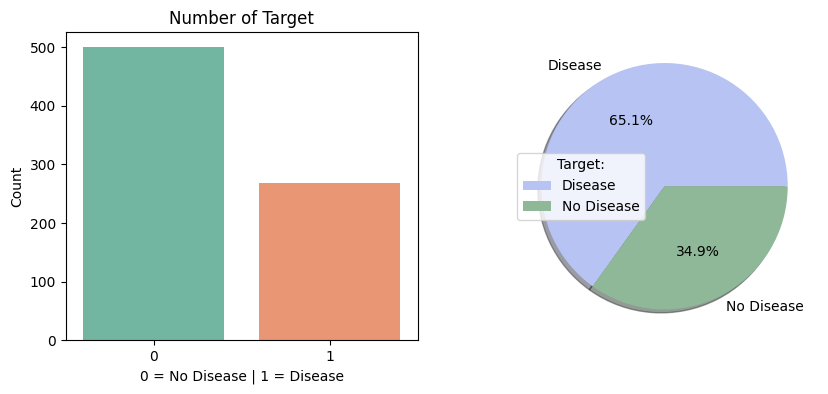

In [19]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x="Outcome", data=data, palette="Set2")
plt.title("Number of Target")
plt.xlabel("0 = No Disease | 1 = Disease")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
target_counts = data['Outcome'].value_counts()
plt.pie(target_counts.values, labels=["Disease", "No Disease"], shadow=True, autopct="%1.1f%%", colors=["#B7C3F3", "#8EB897"])
plt.legend(title="Target:")

plt.show()

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<Axes: >

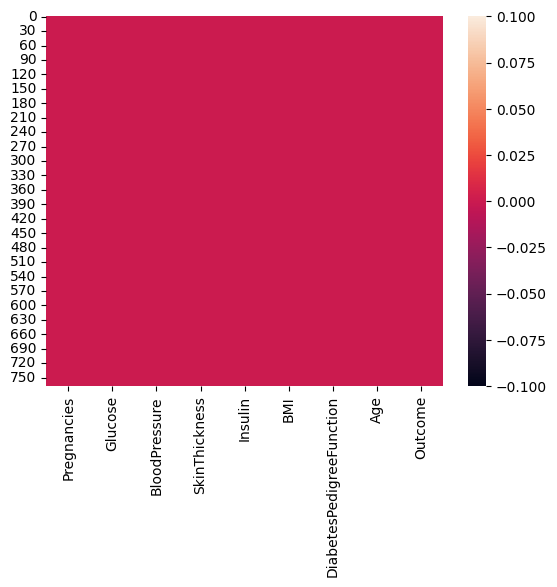

In [21]:
sns.heatmap(data.isnull())

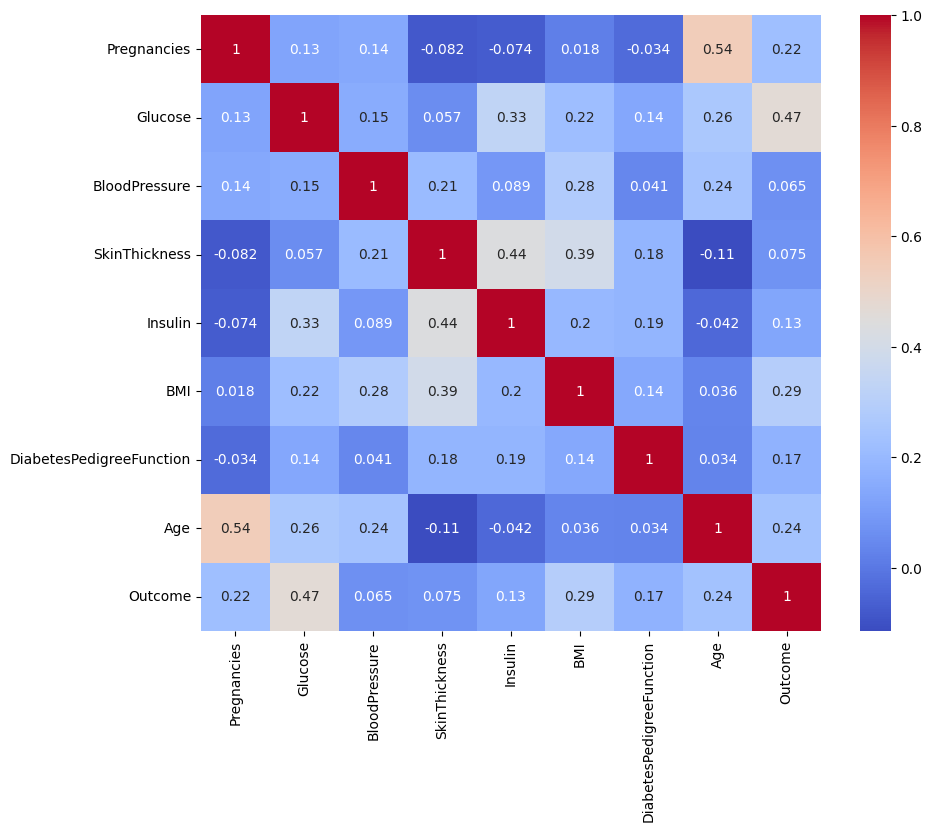

In [22]:
# Get the correlation matrix as a Pandas DataFrame

correlation_matrix = data.corr()

# Set the figure size
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

**Number of Instances:** 768<br/>
**Number of Attributes:** 8 plus target/class<br/>
**For Each Attribute:** (all numeric-valued)

**Pregnancies:** Number of times pregnant <br/>
**Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test <br/>
**BloodPressure:** Diastolic blood pressure (mm Hg)<br/>
**SkinThickness:** Triceps skin fold thickness (mm)<br/>
**Insulin:** 2-Hour serum insulin (mu U/ml)<br/>
**BMI:** Body mass index (weight in kg/(height in m)^2) <br/>
**DiabetesPedigreeFunction:** Diabetes pedigree function <br/>
**Age:** Age (years) <br/>
**Outcome:** Class variable (0 or 1)

In [23]:
#Feature Selection
x = data.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [24]:
y=data['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [26]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=20)

In [27]:
xtrain.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
446,1,100,70,25.3,0.658,28
260,3,191,130,30.9,0.299,34
570,3,78,0,32.5,0.270,39
590,11,111,0,46.8,0.925,45
30,5,109,0,36.0,0.546,60


In [28]:
ytrain.head()

,Outcome
446,0
260,0
570,0
590,1
30,0


In [29]:
model = LogisticRegression()
model.fit(xtrain,ytrain)

LogisticRegression()

In [30]:
predictions = model.predict(xtest)

In [31]:
predictions

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [32]:
ytest.head()

,Outcome
143,1
14,1
504,0
557,0
736,0


In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [34]:
acc = accuracy_score(predictions,ytest)
cm = confusion_matrix(predictions,ytest)

In [35]:
acc

0.7727272727272727

In [36]:
cm

array([[91, 25],
       [10, 28]])

In [37]:
from sklearn.metrics import classification_report

In [38]:
print(classification_report(ytest,predictions))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       101
           1       0.74      0.53      0.62        53

    accuracy                           0.77       154
   macro avg       0.76      0.71      0.73       154
weighted avg       0.77      0.77      0.76       154



# Decision Tree classifier

In [39]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [40]:
#Feature Selection
x = data.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [41]:
y=data['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report

In [43]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=20)

In [44]:
model = DecisionTreeClassifier()
model.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [45]:
pre = model.predict(xtest)

In [46]:
acc=accuracy_score(pre,ytest)
print("Accuracy: ",acc)
cm = confusion_matrix(pre,ytest)
print("Confusion Matrix: \n", cm)
print("Classification Report: \n")
print(classification_report(ytest,pre))

Accuracy:  0.6103896103896104
Confusion Matrix: 
 [[66 25]
 [35 28]]
Classification Report: 

              precision    recall  f1-score   support

           0       0.73      0.65      0.69       101
           1       0.44      0.53      0.48        53

    accuracy                           0.61       154
   macro avg       0.58      0.59      0.59       154
weighted avg       0.63      0.61      0.62       154



# KNN Algorithm

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
from sklearn.metrics import classification_report

In [48]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [49]:
#Feature Selection
x = data.drop(['SkinThickness','BloodPressure','Outcome'],axis=1)

x.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [50]:
y=data['Outcome']
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [51]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2)

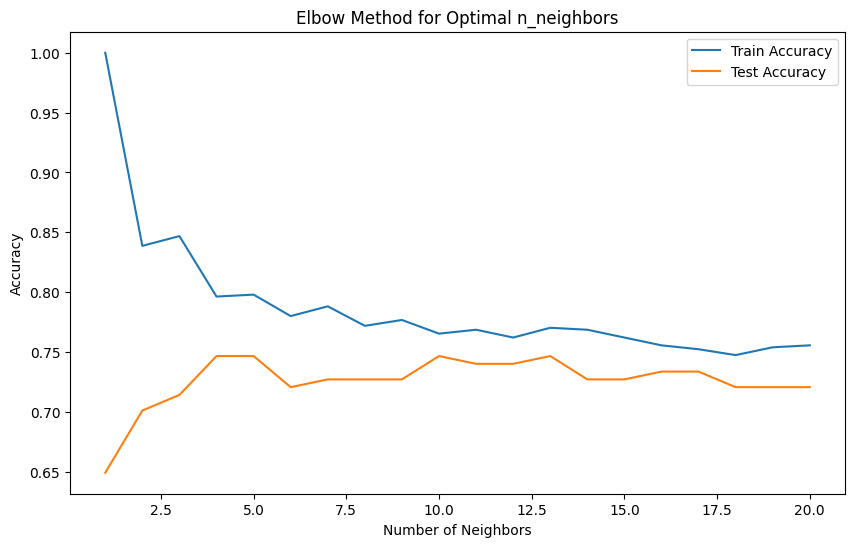

In [52]:
import numpy as np

# Calculate accuracy for different values of n_neighbors
neighbors = np.arange(1, 21)  # Test n_neighbors from 1 to 20
train_accuracy = []
test_accuracy = []

for n in neighbors:
    mdl = KNeighborsClassifier(n_neighbors=n)
    mdl.fit(xtrain, ytrain)
    train_accuracy.append(mdl.score(xtrain, ytrain))
    test_accuracy.append(mdl.score(xtest, ytest))

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracy, label="Train Accuracy")
plt.plot(neighbors, test_accuracy, label="Test Accuracy")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Optimal n_neighbors")
plt.legend()
plt.show()


In [53]:
mdl = KNeighborsClassifier(n_neighbors=3,p=2,metric='euclidean')
mdl.fit(xtrain,ytrain)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [54]:
prediction = mdl.predict(xtest)

In [55]:
print("Accuracy = ", accuracy_score(ytest,prediction))
print("\nConfusion Matrix\n",confusion_matrix(ytest,prediction))
print("\nF1-Score = ",f1_score(ytest,prediction))
print("\nClassification Report\n",classification_report(ytest,prediction))

Accuracy =  0.7142857142857143

Confusion Matrix
 [[88 15]
 [29 22]]

F1-Score =  0.5

Classification Report
               precision    recall  f1-score   support

           0       0.75      0.85      0.80       103
           1       0.59      0.43      0.50        51

    accuracy                           0.71       154
   macro avg       0.67      0.64      0.65       154
weighted avg       0.70      0.71      0.70       154



In [56]:
!pip install openpyxl

In [57]:
import os
os.listdir('/content')

['.config', 'diabetes.csv', 'sample_data']

### Checking for Missing Values

In [58]:
print('Missing values in each column:')
print(data.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Checking for Zero Values in Key Medical Columns
In some columns, a value of 0 might represent a missing or unrecorded measurement rather than an actual zero. Let's count these zero values for 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI'.

In [59]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    num_zeros = (data[col] == 0).sum()
    print(f'Number of zeros in {col}: {num_zeros}')

Number of zeros in Glucose: 5
Number of zeros in BloodPressure: 35
Number of zeros in SkinThickness: 227
Number of zeros in Insulin: 374
Number of zeros in BMI: 11


In [60]:
import pickle

pickle.dump(mdl, open('diabetes_model.pkl', 'wb'))

In [61]:
print(globals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', "import pickle\n\npickle.dump(model, open('diabetes_model.pkl', 'wb'))", "import pickle\n\npickle.dump(mdl, open('diabetes_model.pkl', 'wb'))", 'print(globals())', "# To list all variables\nget_ipython().run_line_magic('who', '')\n\n# To list only the names of variables\nget_ipython().run_line_magic('who_ls', '')", "get_ipython().system('pip install numpy')", "get_ipython().system('pip install numpy')", 'import numpy as np\nprint(np.__version__)', "import pickle\n\npickle.dump(model, open('diabetes_model.pkl', 'wb'))", "import pickle\n\npickle.dump(mdl, open('diabetes_model.pkl', 'wb'))", "mdl = KNeighborsClassifier(n_neighbors=3,p=2,metric='euclidean')\nmdl.fit(xtrain,ytrain)", "import pickle\n\npickle.dump(model, open(

Alternatively, in an IPython environment (like Colab), you can use magic commands to list variables more neatly:

In [62]:
# To list all variables
%who

# To list only the names of variables
%who_ls

DecisionTreeClassifier	 KNeighborsClassifier	 LogisticRegression	 StandardScaler	 acc	 accuracy_score	 classification_report	 cm	 col	 
confusion_matrix	 correlation_matrix	 data	 extract	 f1_score	 mdl	 model	 n	 neighbors	 
np	 num_zeros	 os	 pd	 pickle	 plt	 pre	 prediction	 predictions	 
sns	 target_counts	 test_accuracy	 train_accuracy	 train_test_split	 x	 xtest	 xtrain	 y	 
ytest	 ytrain	 zero_cols	 


['DecisionTreeClassifier',
 'KNeighborsClassifier',
 'LogisticRegression',
 'StandardScaler',
 'acc',
 'accuracy_score',
 'classification_report',
 'cm',
 'col',
 'confusion_matrix',
 'correlation_matrix',
 'data',
 'extract',
 'f1_score',
 'mdl',
 'model',
 'n',
 'neighbors',
 'np',
 'num_zeros',
 'os',
 'pd',
 'pickle',
 'plt',
 'pre',
 'prediction',
 'predictions',
 'sns',
 'target_counts',
 'test_accuracy',
 'train_accuracy',
 'train_test_split',
 'x',
 'xtest',
 'xtrain',
 'y',
 'ytest',
 'ytrain',
 'zero_cols']

In [63]:
!pip install numpy

In [64]:
import numpy as np
print(np.__version__)

2.0.2


In [65]:
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

In [66]:
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

In [67]:
from sklearn.linear_model import LogisticRegression

In [70]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [71]:
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

In [72]:
from sklearn.linear_model import LogisticRegression

In [77]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [78]:
import pickle

with open('diabetes_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully


In [79]:
import os

print(os.path.getsize('diabetes_model.pkl'))

923


In [80]:
from sklearn.linear_model import LogisticRegression
import pickle

# Train model
model = LogisticRegression()
model.fit(xtrain, ytrain)

# Save model
with open('diabetes_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


In [81]:
import os
print(os.path.getsize('diabetes_model.pkl'))

923
